### Task 1 & 2: K-Means Clustering and the Elbow Method
Generating a synthetic blob dataset, finding the optimal number of clusters using the Elbow Method, and plotting the final clustered data alongside their centroids.

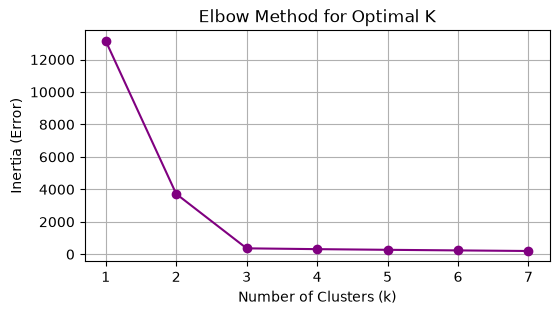

Justification: The big drop stops at k=3, and the curve flattens. Hence, k=3 is the elbow point.


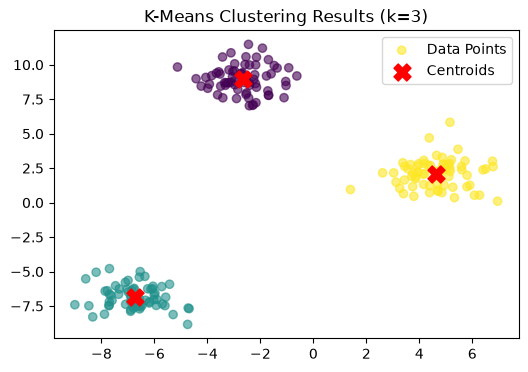

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Generating dynamic blob data (3 natural groups)
X, _ = make_blobs(n_samples=200, centers=3, cluster_std=1.0, random_state=42)

# --- Task 2: Finding the Elbow ---
inertias = []
for k in range(1, 8):
    km_test = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertias.append(km_test.inertia_)

# Plotting the Elbow Curve to justify our K choice
plt.figure(figsize=(6, 3))
plt.plot(range(1, 8), inertias, marker='o', color='purple')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Error)')
plt.grid(True)
plt.show()

print("Justification: The big drop stops at k=3, and the curve flattens. Hence, k=3 is the elbow point.")

# --- Task 1: Running K-Means with k=3 ---
km = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X)
labels = km.labels_
centroids = km.cluster_centers_

# Plotting the final clusters
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.6, label='Data Points')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=150, label='Centroids')
plt.title('K-Means Clustering Results (k=3)')
plt.legend()
plt.show()

### Task 3: Dimensionality Reduction with PCA
Loading a 4-feature dataset (Iris flower data), compressing it into 2 components using PCA, and plotting the reduced data on a 2D scatter plot.

Original Data Shape: (150, 4)
Reduced Data Shape: (150, 2)
Total Information (Variance) Retained: 97.77 %


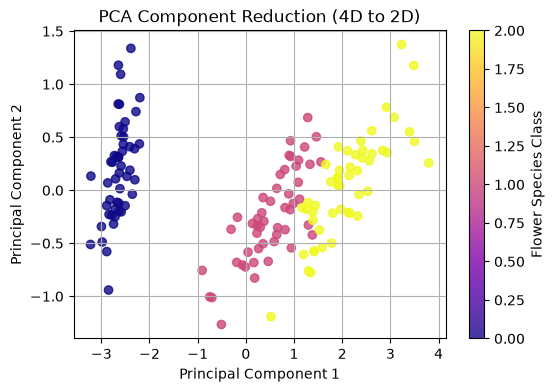

In [2]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

# Loading standard 4-feature Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Applying PCA to drop dimensions from 4 down to 2
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_iris)

print("Original Data Shape:", X_iris.shape)
print("Reduced Data Shape:", X_reduced.shape)
print("Total Information (Variance) Retained:", round(pca.explained_variance_ratio_.sum() * 100, 2), "%")

# Plotting the PCA compressed features
plt.figure(figsize=(6, 4))
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y_iris, cmap='plasma', alpha=0.8)
plt.title('PCA Component Reduction (4D to 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Flower Species Class')
plt.grid(True)
plt.show()

### Task 4: Real Customer Dataset Simulation and Segment Profiling
Here, we simulate a mock Mall Customer dataset containing 'Annual Income' and 'Spending Score' to demonstrate real-world clustering analysis.

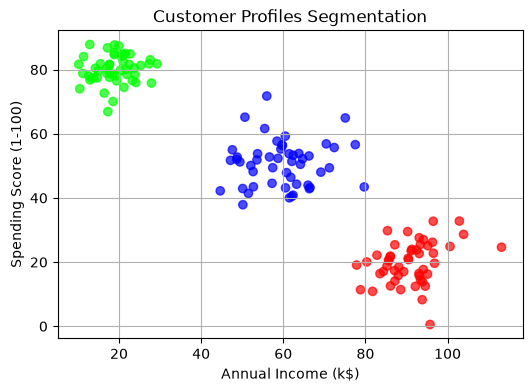

In [3]:
# Simulating standard customer spending habits data
np.random.seed(42)
income_low = np.random.normal(20, 5, 50)
spending_high = np.random.normal(80, 5, 50)

income_mid = np.random.normal(60, 8, 50)
spending_mid = np.random.normal(50, 8, 50)

income_high = np.random.normal(90, 6, 50)
spending_low = np.random.normal(20, 6, 50)

income = np.concatenate([income_low, income_mid, income_high])
spending = np.concatenate([spending_high, spending_mid, spending_low])
customer_data = np.column_stack((income, spending))

# Clustering customers into 3 smart segments
customer_km = KMeans(n_clusters=3, n_init=10, random_state=42).fit(customer_data)
customer_labels = customer_km.labels_

# Plotting Customer Segments
plt.figure(figsize=(6, 4))
plt.scatter(customer_data[:, 0], customer_data[:, 1], c=customer_labels, cmap='brg', alpha=0.7)
plt.title('Customer Profiles Segmentation')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.show()

### Description of What Each Customer Segment Represents:

Based on the statistical cluster positions discovered above, the segments represent three clear consumer profiles:

1. **Segment 0 (Low Income, High Spending):** These are young or highly impulsive buyers who spend heavily despite having lower earnings. They are prime targets for lifestyle promotions and discount vouchers.
2. **Segment 1 (Medium Income, Medium Spending):** These represent regular, conservative middle-class families. Their buying habits are predictable, stable, and highly value-driven.
3. **Segment 2 (High Income, Low Spending):** These represent wealthy, careful shoppers who have deep pockets but do not spend money easily. They are ideal targets for premium, luxury branding or long-term investment schemes.